Loaded 43 articles
Total category assignments: 385
Counter({'introduction': 33, 'methods': 32, 'related work': 31, 'dataset': 29, 'results': 28, 'references': 24, 'appendix': 23, 'discussion': 22, 'future work': 21, 'implementation': 21, 'ai': 18, 'conclusion': 18, 'evaluation': 17, 'acknowledgements': 15, 'limitations': 15, 'abstract': 15, 'experiments': 12, 'keywords': 11})


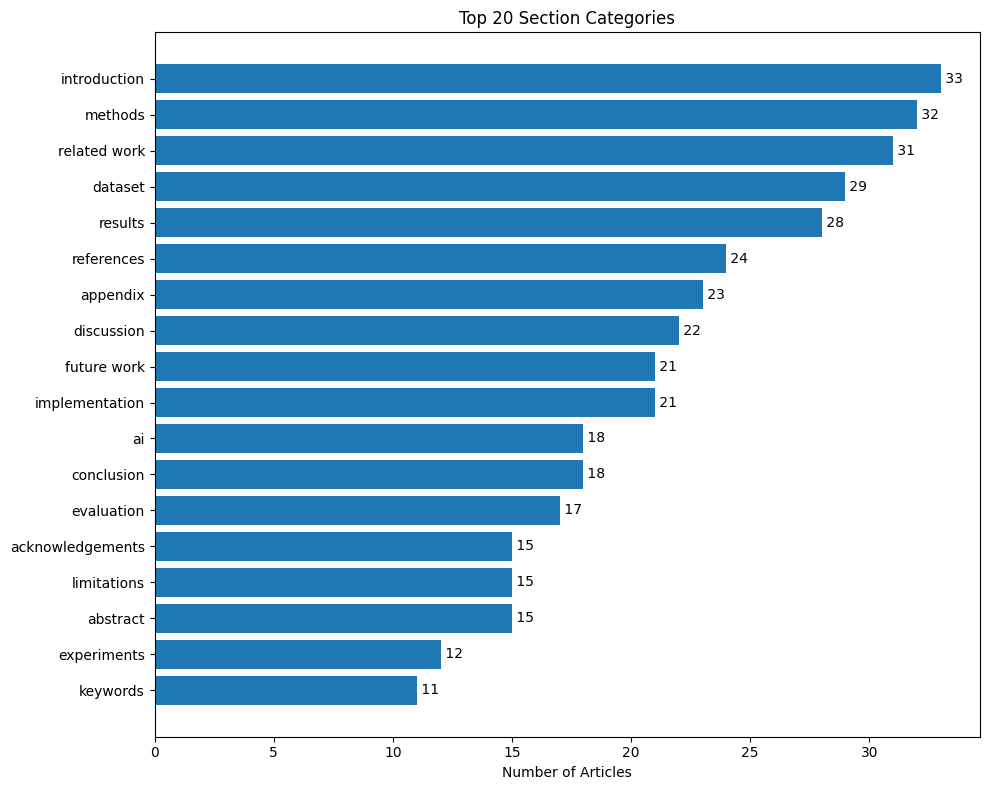

In [ ]:
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.stem import WordNetLemmatizer

# nltk.download("wordnet")
# nltk.download("omw-1.4")


# CONFIG

MD_DIR = "data/md"


# NLP

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"^\d+(\.\d+)*\s*", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)


# CATEGORIES

CATEGORIES = {
    "introduction": "introduction background motivation overview context problem",
    "related work": "related work literature review prior research previous studies",
    "methods": "method methodology approach model algorithm framework architecture training",
    "experiments": "experiment experimental setup design protocol testing setup",
    "results": "results findings performance metrics scores outcomes accuracy",
    "evaluation": "evaluation comparison benchmark validation analysis performance testing",
    "discussion": "discussion interpretation insights explanation reasoning analysis",
    "conclusion": "conclusion summary final remarks takeaways",
    "future work": "future work further research next steps directions",
    "limitations": "limitations weaknesses constraints challenges failure cases",
    "dataset": "dataset data data collection preprocessing features corpus",
    "implementation": "implementation details system design engineering hyperparameters",
    "ai": "prompt llm gpt transformer neural network inference generation model",
    "acknowledgements": "acknowledgements acknowledgments funding support thanks grants",
    "references": "references bibliography citations works cited",
    "appendix": "appendix supplementary additional material",
    "abstract": "abstract summary overview paper contribution",
    "keywords": "keywords key terms topics"
}


# TF-IDF MODEL

category_texts = [preprocess(v) for v in CATEGORIES.values()]
category_names = list(CATEGORIES.keys())

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
category_vectors = vectorizer.fit_transform(category_texts)



# MARKDOWN PARSER

def parse_markdown(md_text):
    sections = []
    current = None

    for line in md_text.split("\n"):
        raw = line
        line = line.strip()

        if not line:
            continue

        if re.match(r"^##+\s+", line):
            heading = re.sub(r"^##+\s*", "", line)

            if current:
                sections.append(current)

            current = {"heading": heading, "text": ""}
            continue

        if current:
            current["text"] += " " + raw

    if current:
        sections.append(current)

    return sections


# CLASSIFIER

def classify_section(name, content):
    text = name + " " + content[:200]
    text = preprocess(text)

    vec = vectorizer.transform([text])
    sims = cosine_similarity(vec, category_vectors)[0]

    best_idx = sims.argmax()
    best_score = sims[best_idx]

    if best_score < 0.15:
        return "other"

    return category_names[best_idx]


# LOAD + AGGREGATE

def load_sections(md_dir):
    article_labels = []

    for file in os.listdir(md_dir):
        if not file.endswith(".md"):
            continue

        path = os.path.join(md_dir, file)

        with open(path, "r", encoding="utf-8") as f:
            md = f.read()

        sections = parse_markdown(md)

        labels_in_article = set()

        for sec in sections:
            label = classify_section(sec["heading"], sec["text"])

            if label != "other":
                labels_in_article.add(label)

        article_labels.extend(labels_in_article)

    return article_labels


# PLOT

def plot(counter, top_n=20):
    most_common = counter.most_common(top_n)

    labels = [x[0] for x in most_common][::-1]
    values = [x[1] for x in most_common][::-1]

    plt.figure(figsize=(10, 8))

    bars = plt.barh(labels, values)

    plt.title("Top 20 Section Categories")
    plt.xlabel("Number of Articles")

    for i, v in enumerate(values):
        plt.text(v, i, f" {v}", va="center")

    plt.tight_layout()
    plt.show()


# MAIN

if __name__ == "__main__":

    labels = load_sections(MD_DIR)

    total_articles = len([f for f in os.listdir(MD_DIR) if f.endswith(".md")])

    print(f"Loaded {total_articles} articles")
    print(f"Total category assignments: {len(labels)}")

    counter = Counter(labels)

    print(counter)

    plot(counter, top_n=20)